:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`custom_dataloader.ipynb`**!

:::

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"
import warnings

# Ignore the specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Creating a custom `DataLoader`

In the previous section we loaded preprocessed arrays (`X` and `spike_trains`) straight into a [`LazyArrayDataLoader`](nemos.batching.LazyArrayDataLoader). Here we start one step earlier, from raw spike times on disk, and build the counts and design matrix on the fly inside the loader.

The spikes are loaded and preprocessed with `pynapple`, which supports lazy, out-of-core loading. The example uses a small simulated dataset, but the same loader scales to large recordings without holding them in memory.

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
import seaborn as sns

from nemos._documentation_utils._stochastic_optim_toy_data import (
    DEFAULT_NWB_PATH,
    _simulate_and_write_to_disk,
)
from nemos._documentation_utils.plotting import (
    plot_batching_schematic,
    plot_loss_history,
)

jax.config.update("jax_enable_x64", True)

import nemos as nmo

nap.nap_config.suppress_conversion_warnings = True

np.random.seed(123)

## The `DataLoader` interface

A [`DataLoader`](nemos.batching.DataLoader) is any object that streams `(X_batch, y_batch)` pairs to [`stochastic_fit`](nemos.glm.PopulationGLM.stochastic_fit). It has to provide three methods:
- `__iter__`: yields `(X_batch, y_batch)` tuples. It is called once at the start of every pass and must return a fresh iterator each time (using `yield` here makes the method a generator, which does this automatically).
- `sample_batch`: a cheap, deterministic batch used once to initialize the solver state.
- `n_samples`: the total number of samples in the dataset.

Anything that provides these three works.

:::{note}
The optimization itself is driven only by `__iter__` and `sample_batch`: `stochastic_fit` iterates the loader for each pass and draws a single `sample_batch` to initialize the solver state. `n_samples` is used *after* fitting, to estimate the residual degrees of freedom and, from those, the scale parameter that the log-likelihood and pseudo-$R^2$ scores depend on. This total count cannot be recovered from a single batch, nor -- for a loader that never materializes the full design matrix -- read off any array's `shape`, so the loader has to report it directly. For observation models with a fixed scale (e.g. Poisson, Bernoulli) the scale is a known constant and this count is never used.
:::

## A Simple Example: `PynappleDataLoader`

As a minimal example, let's define a simple `DataLoader` that builds the design matrix for a fully coupled GLM directly from the spike times, using `pynapple` and a `NeMoS` basis to:

1. sample a random 1 s interval and bin the spikes into counts;
2. pass the counts through a convolutional basis to build the design matrix.

Let's simulate the spike trains first.

In [3]:
_simulate_and_write_to_disk()
data = nap.load_file(DEFAULT_NWB_PATH)
units = data["units"]  # contains spike times per unit
units

  Index     rate
-------  -------
      0  38.8078
      1  28.0856
      2  27.6655
      3  28.4857
      4  28.8858
      5  27.9656
      6  28.9658
      7  28.1056
      8  28.5857
      9  38.8278

Now we are ready to set up the data loader.

In [4]:
class PynappleDataLoader(nmo.batching.DataLoader):
    def __init__(self, spike_times, basis, batch_size, bin_size):
        """Build design-matrix batches on the fly from spike times.

        Parameters
        ----------
        spike_times : pynapple.TsGroup
            Spike times, one entry per unit.
        basis : nemos.basis.Basis
            Convolutional basis used to build the design matrix from binned counts.
        batch_size : float
            Batch duration, in seconds.
        bin_size : float
            Bin width for counting spikes, in seconds.
        """
        self.spike_times = spike_times
        self.basis = basis
        self.batch_size = batch_size
        self.bin_size = bin_size
        self.n_batches_per_epoch = int(
            spike_times.time_support.tot_length() // self.batch_size
        )
        self.rng = np.random.default_rng(seed=123)

        self._sample_batch = None

    def __iter__(self):
        """
        Yield one batch per step for a full pass.

        Defining this is what lets `stochastic_fit` loop over the loader
        (`for X_batch, y_batch in loader`) one batch at a time.
        It is called once at the start of every pass, so it has to begin a
        fresh pass over the data each time. Using `yield` here (which turns
        the method into a generator) takes care of that automatically.
        """
        for i in range(self.n_batches_per_epoch):
            yield self._random_batch()

    @property
    def n_samples(self):
        """Number of samples in the full dataset"""
        return int(np.round(self.spike_times.time_support.tot_length() / self.bin_size))

    def sample_batch(self):
        """Generate a sample batch at the start of the time support."""
        if self._sample_batch is None:
            self._sample_batch = self._batch_at_t(self.spike_times.time_support[0, 0])

        return self._sample_batch

    def _batch_at_t(self, t: float):
        """Generate a batch starting at time t."""
        ep = nap.IntervalSet(t, t + self.batch_size)
        counts = self.spike_times.restrict(ep).count(self.bin_size)
        X = self.basis.compute_features(counts)

        return X, counts

    def _random_batch(self):
        """Generate a batch at a random time within the time support."""
        t = self.rng.uniform(
            self.spike_times.time_support[0, 0],
            self.spike_times.time_support[0, 1] - self.batch_size,
        )
        return self._batch_at_t(t)

:::{note}
For best performance (i.e. to avoid unnecessary function recompilations), generate batches that all have the same or at least a limited number of distinct sizes.
:::

Let's instantiate it and get a batch.

In [5]:
batch_size = 1  # seconds
bin_size = 0.005  # seconds
window_size = int(0.2 / bin_size) # bins

# define a convolutional basis
basis = nmo.basis.RaisedCosineLogConv(5, window_size=window_size)
loader = PynappleDataLoader(units, basis, batch_size, bin_size)

X_batch, y_batch = loader.sample_batch()
print(X_batch)

Time (s)                          0             1           2          3          4  ...
--------------------  -------------  ------------  ----------  ---------  ---------  -----
0.0025                nan            nan           nan         nan        nan        ...
0.0075                nan            nan           nan         nan        nan        ...
0.0125                nan            nan           nan         nan        nan        ...
0.017499999999999998  nan            nan           nan         nan        nan        ...
0.0225                nan            nan           nan         nan        nan        ...
0.0275                nan            nan           nan         nan        nan        ...
0.0325                nan            nan           nan         nan        nan        ...
...                                                                                  ...
0.9674999999999999      0.302096       0.959167      0.838925    1.1064     4.25361  ...
0.9724999999999999 

:::{admonition} NaN padding
:class: note

The first `window_size` rows of the design matrix are NaNs. This is NeMoS default convolution behavior: the convolution is run in mode `"valid"` to avoid border artifact and then NaN padded to preserve the original time axis length. NeMoS `GLM.stochastic_fit` will filter out the NaNs, so the effective batch size will be `160 = 200 - window_size`.
:::


### Set up logging and run the optimization

We again use the preprocessed full dataset as the test set, but in practice this would be a smaller held-out dataset.

In [6]:
batch_logger = nmo.callbacks.TestLossLogger(
    data["X"],
    data["spike_trains"],
    events={"train_begin", "batch_end"},
)

Fit for 30 passes:

In [7]:
glm = nmo.glm.PopulationGLM(
    solver_name="GradientDescent",
    regularizer="Ridge",
    regularizer_strength=0.01,
    solver_kwargs={"stepsize": 0.05, "acceleration": False},
)

In [8]:
glm.stochastic_fit(loader, n_passes=30, callbacks=batch_logger)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f83ed736980>
,regularizer,Ridge()
,regularizer_strength,0.01
,solver_name,'GradientDescent'
,solver_kwargs,"{'acceleration': False, 'stepsize': 0.05}"
,feature_mask,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](50, 10)",Array([[-9.74...dtype=float64)
dof_resid_,NoneType,None


<Axes: xlabel='Log index (~batch index)', ylabel='Loss value'>

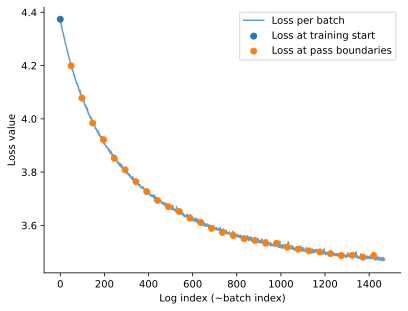

In [9]:
plot_loss_history(batch_logger.loss_history)

## Handling Disjoint Recording Intervals

Next we build a `DataLoader` for a common real-world case: sampling batches from a discontinuous recording. Often only parts of a recording are of interest -- valid trials, periods when the subject is engaged in the task, and so on.

Let's simulate this scenario by chunking generated spike trains in three epochs. In `pynapple` terms, this is equivalent of restricting the time series to a multi-epoch `IntervalSet`.

In [10]:
recording = nap.IntervalSet(start=[0.0, 25.0, 42.0], end=[20.0, 40.0, 50.0])
units = units.restrict(recording)
units.time_support

  index    start    end
      0        0     20
      1       25     40
      2       42     50
shape: (3, 2), time unit: sec.

### Batching a fully coupled GLM

The design matrix comes from convolving the spike counts with a basis, and it is this convolution that makes batching a discontinuous recording non-trivial: a batch must not convolve across the gap between two intervals, and the batches should have a small number of distinct sizes (each new size recompiles the update step).

The simplest way to keep batches from crossing a gap is to build them as contiguous chunks. We use pynapple's `IntervalSet.split` to cut each recording interval into equal-duration chunks -- so a chunk never spans a gap -- and visit them in a random order on every pass over the dataset. Reshuffling the chunk order each pass decorrelates successive gradient steps and covers every chunk exactly once. Because `split` emits only full `interval_size` pieces, it drops the leftover tail whenever `interval_size` does not divide an interval's duration, along with any interval shorter than `interval_size`; the *Use all samples* note after the loader shows how to keep them.

As we have seen before, the first `window_size` of each batch is filled with NaNs that will be dropped at fit time. We will enforce an effective batch (batch size after dropping the NaNs) by extending the chunk of data of an extra *context* of `window_size` bin length. These context bins exist only to supply history to the chunk's first real bins; they are not training samples themselves.

The construction is sketched below (bin counts are illustrative, not to scale):

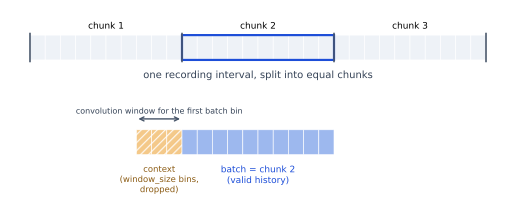

In [11]:
plot_batching_schematic();

Putting the pieces together:

In [12]:
class MultiEpochPynappleDataLoader(nmo.batching.DataLoader):
    def __init__(self, spike_times, basis, interval_size, bin_size, shuffle=True, seed=123):
        """Build gap-safe design-matrix batches from a discontinuous recording.

        Parameters
        ----------
        spike_times : pynapple.TsGroup
            Spike times, one entry per unit; its ``time_support`` may hold multiple intervals.
        basis : nemos.basis.Basis
            Convolutional basis used to build the design matrix from binned counts.
        interval_size : float
            Chunk duration, in seconds.
        bin_size : float
            Bin width for counting spikes, in seconds.
        shuffle : bool, default True
            Whether to reshuffle the chunk order on every pass.
        seed : int, default 123
            Seed for the chunk-shuffling RNG.
        """
        self.spike_times = spike_times
        self.basis = basis
        self.bin_size = bin_size
        # the context_duration is the length of the context in seconds
        self.context_duration = basis.window_size * bin_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)

        # Split each recording interval into interval_size chunks with pynapple, so none crosses a
        # gap. `split` drops the sub-interval_size tail of every interval (and any interval shorter
        # than interval_size); see the note above for a numpy alternative that keeps them. It returns
        # only (start, end), so we re-attach each chunk's parent-interval start via searchsorted, used
        # to clip the left context without reaching back across a gap.
        chunks = spike_times.time_support.split(interval_size)
        starts = spike_times.time_support.start
        interval_start = starts[np.searchsorted(starts, chunks.start, side="right") - 1]
        self._chunks = np.column_stack([chunks.start, chunks.end, interval_start])

    @property
    def n_samples(self):
        """Number of samples in the full dataset."""
        return int(round(self.spike_times.time_support.tot_length() / self.bin_size))

    def _batch(self, start, end, interval_start):
        """Count and convolve one chunk, prepending a window of history for the convolution."""
        start_ext = max(start - self.context_duration, interval_start)
        counts = self.spike_times.count(self.bin_size, ep=nap.IntervalSet(start_ext, end))
        return self.basis.compute_features(counts), counts

    def sample_batch(self):
        """Deterministic first-chunk batch used to initialize the solver state."""
        return self._batch(*self._chunks[0])

    def __iter__(self):
        """Yield one batch per chunk, reshuffling the chunk order at each pass over the data."""
        chunks = self._chunks
        if self.shuffle:
            chunks = chunks[self.rng.permutation(len(chunks))]
        for start, end, interval_start in chunks:
            yield self._batch(start, end, interval_start)

:::{dropdown} Use all samples
:color: info

As mentioned in the main text, `split` may drop some time points. To train on the whole sample axis, replace the `split`/`searchsorted` lines in the constructor with a manual `numpy` split that keeps the short final tail and each chunk's parent-interval start:

```python
def split_intervals(time_support, interval_size):
    """Split each interval into `interval_size` chunks, keeping the short final tail.

    Each row is ``(chunk_start, chunk_end, interval_start)``; ``interval_start`` lets the
    loader clip the left context without reaching back into the previous interval.
    """
    return np.array([
        (start_chunk, min(start_chunk + interval_size, end), start)
        for start, end in time_support.values
        for start_chunk in np.arange(start, end, interval_size)
    ])
```

It returns the same `(chunk_start, chunk_end, interval_start)` rows the loader expects, so `self._chunks = split_intervals(spike_times.time_support, interval_size)` is a drop-in replacement for those three lines.
:::

### Defining the Loader & Running The Optimization

The loader can be defined as before.

In [13]:
batch_size = 5  # seconds
window_size_sec = window_size * bin_size

# interval_size = batch_size + window_size_sec
interval_size = batch_size + window_size_sec  # seconds

loader = MultiEpochPynappleDataLoader(units, basis, interval_size, bin_size)

X_batch, y_batch = loader.sample_batch()

# Check the effective batch size after dropping nans
print(f"Effective batch size: {X_batch.dropna().shape[0] * bin_size} secs")

Effective batch size: 5.0 secs


:::{note}
This loader re-bins and re-convolves the data on every pass. If the design matrix is larger than RAM but fits on disk, it is faster to compute it once and store it in a memory-mappable format that `pynapple` [loads lazily](https://pynapple.org/user_guide/02_input_output.html) -- Zarr, HDF5, NWB, or similar -- then stream it with [`LazyArrayDataLoader`](nemos.batching.LazyArrayDataLoader), as in the [basics section](./stochastic_fit.md).
:::

We again use the preprocessed full dataset as the test set, but in practice this would be a smaller held-out dataset.

In [14]:
batch_logger = nmo.callbacks.TestLossLogger(
    data["X"],
    data["spike_trains"],
    events={"train_begin", "batch_end"},
)

Fit for 30 passes:

In [15]:
glm = nmo.glm.PopulationGLM(
    solver_name="GradientDescent",
    regularizer="Ridge",
    regularizer_strength=0.01,
    solver_kwargs={"stepsize": 0.05, "acceleration": False},
)

In [16]:
glm.stochastic_fit(loader, n_passes=30, callbacks=batch_logger)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f83ed736980>
,regularizer,Ridge()
,regularizer_strength,0.01
,solver_name,'GradientDescent'
,solver_kwargs,"{'acceleration': False, 'stepsize': 0.05}"
,feature_mask,None
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](50, 10)",Array([[-3.23...dtype=float64)
dof_resid_,NoneType,None


<Axes: xlabel='Log index (~batch index)', ylabel='Loss value'>

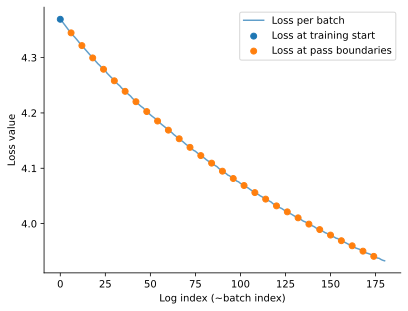

In [17]:
plot_loss_history(batch_logger.loss_history)